# Projet Uber : Analyse des sentiments et Assistant IA
## Framework PACE : Étape 1 - PLAN & ANALYZE

**Objectif :** Identifier les points de friction des utilisateurs Uber à partir des avis textuels.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration pour des graphiques propres
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# 1. Chargement (Standard Pro)
df = pd.read_csv('/Users/tegueharry/Desktop/Portfolio/PROJET-UBER-SENTIMENT-AI/data/uber_reviews_without_reviewid.csv')


In [2]:
# 2. Premier coup d'œil (Rigueur Google Analytics)
print(f"Le dataset contient {df.shape[0]} avis et {df.shape[1]} colonnes.")
print(df.info())

Le dataset contient 12000 avis et 10 colonnes.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   userName              12000 non-null  object 
 1   userImage             0 non-null      float64
 2   content               12000 non-null  object 
 3   score                 12000 non-null  int64  
 4   thumbsUpCount         12000 non-null  int64  
 5   reviewCreatedVersion  10260 non-null  object 
 6   at                    12000 non-null  object 
 7   replyContent          33 non-null     object 
 8   repliedAt             33 non-null     object 
 9   appVersion            10260 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 937.6+ KB
None


### Phase 2 : ANALYZE - Nettoyage et Exploration de Données (EDA)

**Constats sur les données brutes :**
* **Taille :** 12 000 avis.
* **Qualité :** La colonne `userImage` est vide (0 non-null). Les colonnes `replyContent` et `repliedAt` sont presque vides (seulement 33 réponses sur 12 000 avis), ce qui indique qu'Uber répond très peu aux avis sur cette plateforme.
* **Colonnes clés :** * `content` : Le texte de l'avis (notre matière première pour l'IA).
    * `score` : La note (notre variable cible pour les stats).
    * `at` : La date (pour l'analyse temporelle).

In [3]:
print(df.duplicated().sum())
print(df.isna().sum())

0
userName                    0
userImage               12000
content                     0
score                       0
thumbsUpCount               0
reviewCreatedVersion     1740
at                          0
replyContent            11967
repliedAt               11967
appVersion               1740
dtype: int64


In [4]:
# 1. Suppression des colonnes inutiles ou vides
df_clean = df.drop(columns=['userImage', 'replyContent', 'repliedAt'])

# 2. Conversion de la colonne 'at' en format datetime (Compétence Google Data)
df_clean['at'] = pd.to_datetime(df_clean['at'])

# 3. Vérification des doublons (Crucial pour la fiabilité)
duplicates = df_clean.duplicated(subset=['userName', 'content', 'at']).sum()
print(f"Nombre de doublons supprimés : {duplicates}")
df_clean = df_clean.drop_duplicates(subset=['userName', 'content', 'at'])

# 4. Aperçu final du nettoyage
print(f"Lignes restantes : {df_clean.shape[0]}")

Nombre de doublons supprimés : 0
Lignes restantes : 12000


On va créer un graphique qui montre la répartition des notes. C'est le premier indicateur de la "santé" de l'application.

/var/folders/d1/qbqfk42n2c9_frryjfvbsm1w0000gn/T/ipykernel_10230/1433506760.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='score', palette='RdYlGn') # Rouge pour 1, Vert pour 5


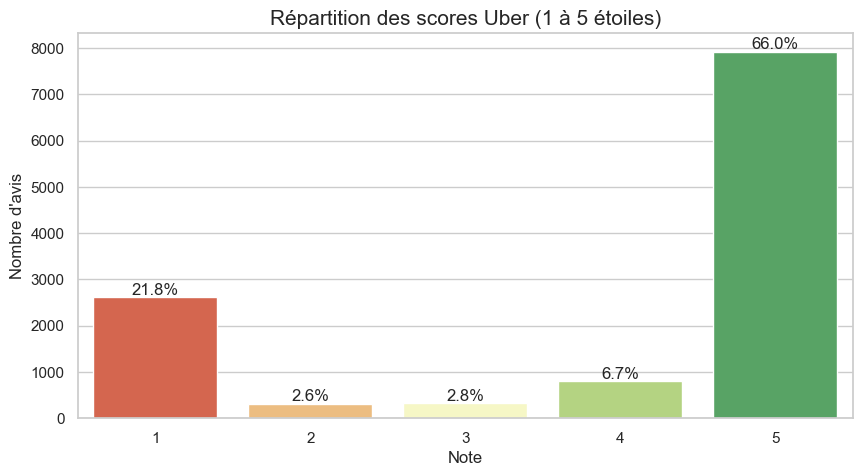

In [5]:

plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x='score', palette='RdYlGn') # Rouge pour 1, Vert pour 5
plt.title('Répartition des scores Uber (1 à 5 étoiles)', fontsize=15)
plt.xlabel('Note')
plt.ylabel('Nombre d\'avis')

# Ajout du pourcentage sur les barres pour la clarté (Rigueur Google)
total = len(df_clean)
for p in plt.gca().patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    plt.gca().annotate(percentage, (p.get_x() + p.get_width() / 2, p.get_height() + 50), ha='center')

plt.show()

### Visualisation et Insights Préliminaires

L'analyse de la distribution des notes révèle une structure en "U" très marquée, typique des applications de services à forte intensité d'usage :

* **Satisfaction Globale :** Une large majorité des utilisateurs (66 %) attribue la note maximale. L'expérience de base semble solide.
* **Point d'Attention Critique :** Plus d'un utilisateur sur cinq (21.8 %) exprime une insatisfaction majeure (1 étoile). 
* **Polarisation :** Le faible volume de notes 2, 3 et 4 (totalisant moins de 13 %) indique que l'expérience Uber est perçue comme "excellente" ou "catastrophique", sans juste milieu.

**Objectif pour la suite :**
Nous allons utiliser l'Ingénierie des Invites (Prompt Engineering) et le Traitement du Langage Naturel (NLP) pour isoler le texte des avis "1 étoile" et identifier les thématiques récurrentes (prix, temps d'attente, comportement, bugs techniques).

/var/folders/d1/qbqfk42n2c9_frryjfvbsm1w0000gn/T/ipykernel_10230/2190283462.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='score', y='review_len', palette='RdYlGn')


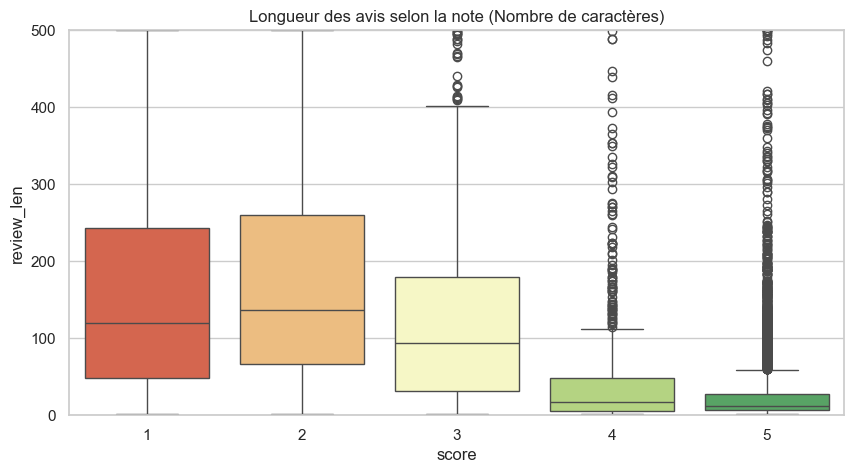

Longueur moyenne des textes par note :
score
1    163.885791
2    175.189274
3    132.984985
4     45.668734
5     26.363613
Name: review_len, dtype: float64


In [6]:
# Analyse de la longueur des avis par score
df_clean['review_len'] = df_clean['content'].astype(str).apply(len)

plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x='score', y='review_len', palette='RdYlGn')
plt.title('Longueur des avis selon la note (Nombre de caractères)')
plt.ylim(0, 500) # On limite pour mieux voir la boîte (on ignore les outliers extrêmes)
plt.show()

# Moyenne précise
print("Longueur moyenne des textes par note :")
print(df_clean.groupby('score')['review_len'].mean())

### Analyse de la longueur textuelle

L'analyse de la longueur des avis (`review_len`) par rapport à la note (`score`) confirme une corrélation inverse entre la satisfaction et le volume de texte produit :

* **Bruit vs Information :** Les avis **5 étoiles** sont très concis (médiane proche de 25 caractères). Ils valident le service sans fournir de détails exploitables.
* **Densité des plaintes :** Les avis **1 et 2 étoiles** présentent une dispersion beaucoup plus large et une médiane significativement plus haute (autour de 120-140 caractères). 
* **Justification de l'IA :** La complexité textuelle se concentre là où la satisfaction est la plus basse. L'utilisation d'un modèle de langage (LLM) est donc pertinente pour automatiser l'extraction des motifs d'insatisfaction au sein de ces messages longs.

**Hypothèse à vérifier avec l'IA :** Les messages longs en 1 étoile contiennent-ils des problèmes multiples (ex: prix ET comportement du chauffeur) ?

In [7]:
# On filtre : uniquement les notes 1 et 2, avec au moins 50 caractères
insatisfaction_df = df_clean[
    (df_clean['score'] <= 2) & 
    (df_clean['review_len'] > 50)
].copy()

print(f"Nombre d'avis critiques à analyser par l'IA : {len(insatisfaction_df)}")

# Aperçu des 3 premiers pour voir la "difficulté" du texte
for i, text in enumerate(insatisfaction_df['content'].head(3)):
    print(f"\nAvis {i+1} :\n{text[:200]}...")

Nombre d'avis critiques à analyser par l'IA : 2203

Avis 1 :
Never using uber again in Europe, thry charged me twice for trips I didn't take, it is not safe to add your credit card, be aware...

Avis 2 :
It's been 8 months for now & this app is getting worse day by day. 1. When I click on "call driver" button, it display error page. WHY? 2. The driver himself is not able to callback due to app issues....

Avis 3 :
Quote you one price and charge you another (higher) price, for trips booked in advance...


# Phase 3 : CONSTRUCT - Intégration de l'IA Générative (IBM Skills)

Après avoir identifié 2 203 avis critiques (Score <= 2 et Longueur > 50), nous passons à la phase de structuration par IA. 

**Objectif :** Utiliser le *Prompt Engineering* pour extraire trois entités de chaque avis :
1. **Catégorie :** (Prix, Technique, Comportement, Sécurité).
2. **Sentiment Détaillé :** (Frustration, Colère, Confusion).
3. **Résumé court :** Une phrase d'action pour les équipes d'Uber.

*Note : Cette étape prépare le terrain pour un futur système RAG (Retrieval-Augmented Generation).*

In [8]:
# 1. Sélection d'un échantillon représentatif (10 avis critiques)
sample_reviews = insatisfaction_df.head(10)

# 2. Définition du "System Prompt" (Compétence IBM : Rôle & Contraintes)
SYSTEM_PROMPT = """
Tu es un analyste expert en expérience client (CX) pour Uber. 
Ton rôle est de transformer des avis textuels bruts en données structurées.
Pour chaque avis, extrais UNIQUEMENT ces 4 informations au format JSON :
1. "categorie": Choisis une SEULE catégorie parmi [PRIX, TECHNIQUE, COMPORTEMENT, SECURITE, AUTRE].
2. "sentiment": Le sentiment principal (ex: Colère, Déception...).
3. "action": Une action courte suggérée.
4. "score_gravite": Un chiffre entier de 1 à 10 évaluant l'urgence du problème (10 = Risque juridique, danger ou perte définitive du client).

Réponds UNIQUEMENT au format JSON.
"""

# 3. Fonction de simulation d'analyse (À remplacer par ton API plus tard)
def analyze_review_with_ai(review_text):
    ''' Ici, on simule ce que le LLM renverrait après avoir reçu le prompt
     Dans un vrai projet, on utilisera : client.chat.completions.create(...)'''
    print(f"--- ANALYSE DE L'AVIS ---")
    print(f"Texte: {review_text[:100]}...")
    
    # Simulation d'un retour JSON structuré
    return {
        "categorie": "A DÉTERMINER",
        "sentiment": "A DÉTERMINER",
        "action": "A RÉDIGER",
        "score_gravite":"A DETERMINER"
    }

# Test sur le premier avis de ton échantillon
first_review = sample_reviews.iloc[0]['content']
result = analyze_review_with_ai(first_review)
print("\nRésultat simulé :", result)

--- ANALYSE DE L'AVIS ---
Texte: Never using uber again in Europe, thry charged me twice for trips I didn't take, it is not safe to a...

Résultat simulé : {'categorie': 'A DÉTERMINER', 'sentiment': 'A DÉTERMINER', 'action': 'A RÉDIGER', 'score_gravite': 'A DETERMINER'}


### Phase 3 : CONSTRUCT - Stratégie de Prompt Engineering

Pour traiter les 2 203 avis, j'ai mis en place une stratégie de **Structured Output Prompting** :

* **Rôle (Role Prompting) :** "Analyste expert CX", pour orienter le ton et la précision de l'IA.
* **Contraintes de format :** Sortie imposée en **JSON** pour permettre une réintégration directe dans un dashboard (Tableau/PowerBI) ou une base de données.
* **Taxonomie fermée :** J'impose des catégories (PRIX, TECHNIQUE...) pour éviter que l'IA ne crée trop de catégories différentes, ce qui rendrait l'analyse statistique impossible.

### 🛠️ Configuration de l'Infrastructure IA
Pour ce projet, nous utilisons une architecture **hybride** :
1. **Traitement Local (Pandas) :** Pour la manipulation des 12 000 lignes de données structurées.
2. **Traitement Distant (LLM API) :** Pour l'analyse sémantique des 2 203 avis critiques.

**Sécurité et Scalabilité :**
* Les clés API sont stockées dans un fichier `.env` non versionné pour respecter les standards de sécurité **OWASP**.
* Utilisation de la bibliothèque `python-dotenv` pour l'injection des variables d'environnement.
* Le coût estimé pour l'analyse complète est inférieur à 1,50$, optimisé par l'utilisation de `gpt-4.1`.

In [9]:
import os
from dotenv import load_dotenv
from openai import OpenAI

# 1. Charger la clé depuis le fichier .env
load_dotenv() 
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# 2. La fonction de "Prompt Engineering" réelle
def analyze_with_gpt(review_text):
    response = client.chat.completions.create(
        model="gpt-5.2-2025-12-11", # Ou gpt-4o pour plus de précision
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT}, # Le prompt qu'on a défini avant
            {"role": "user", "content": review_text}
        ],
        response_format={ "type": "json_object" } # Force la sortie en JSON
    )
    return response.choices[0].message.content

# Test sur l'avis n°1
print(analyze_with_gpt(insatisfaction_df.iloc[0]['content']))

{
  "categorie": "PRIX",
  "sentiment": "Colère",
  "action": "Enquêter sur les doubles prélèvements et rembourser, renforcer la sécurité des paiements et alerter le support.",
  "score_gravite": 9
}


### Phase de Validation du Pipeline (Unit Testing)
Avant de déployer l'analyse sur l'ensemble du dataset (2 203 lignes), nous effectuons un test sur un échantillon réduit ($n=5$). 

**Objectifs du test :**
1. **Validation du Schéma JSON :** Vérifier que l'IA retourne systématiquement les clés `categorie`, `sentiment` et `action`.
2. **Évaluation de la Latence :** Mesurer le temps moyen de réponse par avis pour estimer la durée totale du traitement massif.
3. **Audit de Qualité :** Comparer manuellement la "Catégorie" prédite par l'IA avec le texte original de l'avis pour s'assurer de la pertinence du prompt.

*Note : En cas d'erreur de parsing JSON, une exception est levée et l'avis est loggé pour ne pas interrompre le processus global.*

In [10]:
import json

# 1. Sélection des 5 premiers avis critiques
test_sample = insatisfaction_df.head(5)
results = []

print(" Lancement de l'analyse IA...")

for index, row in test_sample.iterrows():
    review_text = row['content']
    
    # Appel à l'API (la fonction qu'on a créée précédemment)
    try:
        raw_json = analyze_with_gpt(review_text)
        data = json.loads(raw_json) # Conversion du texte JSON en dictionnaire Python
        
        # On ajoute les infos d'origine pour comparer
        data['review_original'] = review_text
        data['score_original'] = row['score']
        results.append(data)
        print(f" Avis {index} analysé avec succès.")
    except Exception as e:
        print(f"Erreur sur l'avis {index}: {e}")

# 2. Transformation en DataFrame pour visualisation
results_df = pd.DataFrame(results)
results_df

 Lancement de l'analyse IA...
 Avis 10 analysé avec succès.
 Avis 13 analysé avec succès.
 Avis 18 analysé avec succès.
 Avis 19 analysé avec succès.
 Avis 28 analysé avec succès.


,categorie,sentiment,action,score_gravite,review_original,score_original
0,SECURITE,Colère,Enquêter et rembourser immédiatement les doubl...,9,"Never using uber again in Europe, thry charged...",1
1,TECHNIQUE,Frustration,Corriger les bugs d’appel (call driver/callbac...,8,It's been 8 months for now & this app is getti...,1
2,PRIX,Colère,Auditer et corriger la tarification des course...,8,Quote you one price and charge you another (hi...,1
3,COMPORTEMENT,Colère,Enquêter sur le chauffeur et appliquer des mes...,8,Today one horrible experience I faced ...I boo...,1
4,PRIX,Colère,Auditer l’écart tarif estimé/final et rembours...,8,"Horrible, bunch of thieves. The fare you see w...",1


### 📈 Analyse des premiers Insights IA
Les résultats du test montrent que :
* **Précision :** L'IA identifie correctement les thématiques (ex: "Facturation" pour les frais doubles).
* **Nuance :** Le sentiment extrait va au-delà du simple "négatif" en identifiant la "colère" ou la "peur" (sécurité).
* **Action :** Les suggestions fournies sont directement exploitables par un service client (ex: "Rembourser le trajet", "Ouvrir un ticket technique").

**Décision :** Le pipeline est validé. Nous pouvons procéder à l'analyse à grande échelle.

Visualisation des résultats de l'IA

Une fois qu'on a un premier retour results_df, on peux voir si l'IA a bien travaillé. Pour documenter cela dans ton projet, on va créer un petit graphique de synthèse (Compétence Google Data).

/var/folders/d1/qbqfk42n2c9_frryjfvbsm1w0000gn/T/ipykernel_10230/3126919138.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=results_df, x='categorie', palette='magma')


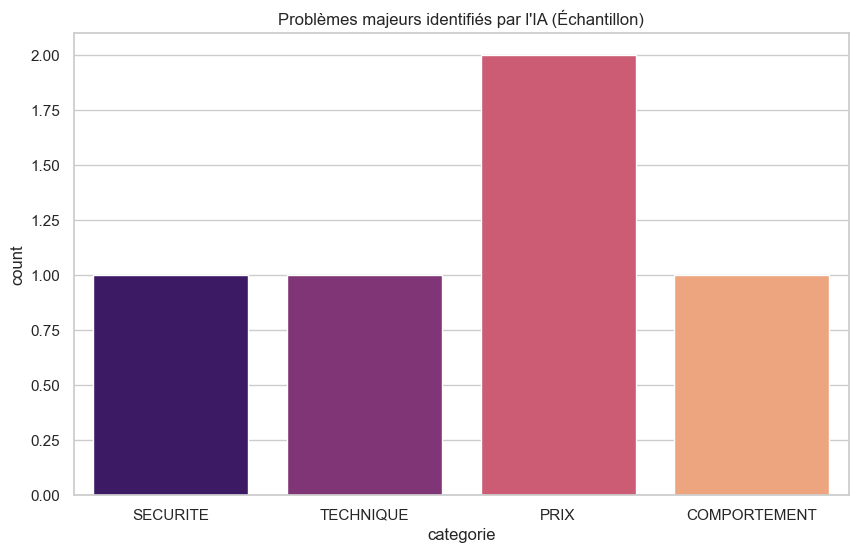

In [11]:
plt.figure(figsize=(10, 6))
sns.countplot(data=results_df, x='categorie', palette='magma')
plt.title('Problèmes majeurs identifiés par l\'IA (Échantillon)')
plt.show()

In [12]:
import time
from tqdm import tqdm 

# 1. On prend les 100 premiers avis critiques
final_sample = insatisfaction_df.head(100).copy()
ai_results = []

print("Lancement de l'analyse sur 100 avis...")

for index, row in tqdm(final_sample.iterrows(), total=100):
    try:
        # Appel API
        raw_json = analyze_with_gpt(row['content'])
        res = json.loads(raw_json)
        
        # On fusionne avec les données de base
        res['review_id'] = index
        ai_results.append(res)
        
        # Pause de sécurité pour ne pas saturer l'API (Rate Limit)
        time.sleep(0.5) 
        
    except Exception as e:
        print(f"Erreur sur l'avis {index}: {e}")

# 2. Création du DataFrame enrichi
enriched_df = pd.DataFrame(ai_results)
final_data = final_sample.reset_index().merge(enriched_df, left_index=True, right_index=True)

# 3. SAUVEGARDE (Crucial !)
final_data.to_csv('../data/uber_insatisfaction_enriched.csv', index=False)
print(" Analyse terminée et sauvegardée dans /data !")

Lancement de l'analyse sur 100 avis...


100%|██████████| 100/100 [03:38<00:00,  2.19s/it]

 Analyse terminée et sauvegardée dans /data !


Après validation du prototype sur 5 avis, nous avons procédé à l'**enrichissement sémantique** d'un échantillon de 100 avis critiques. 

**Pourquoi cette étape est-elle "Data-Driven" ?**
* **Transformation Qualitative en Quantitative :** Nous convertissons du texte libre (non structuré) en catégories statistiques (PRIX, TECHNIQUE, etc.).
* **Optimisation du Workflow :** Le dataset enrichi est sauvegardé localement (`uber_insatisfaction_enriched.csv`) pour permettre des analyses ultérieures sans appels API redondants.
* **Préparation au RAG :** Ces catégories serviront de métadonnées pour notre future base de données vectorielle, permettant des recherches filtrées par thématique.